In [89]:
import yfinance as yf
msft = yf.Ticker("MPC")
aapl = yf.Ticker("PSX")
df_msft=msft.history(period="40y")
df_apple=aapl.history(period="40y")

In [90]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from sklearn.linear_model import LinearRegression
np.random.seed(9823)

df_msft.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3736.000000,3736.000000,3736.000000,3736.000000,3.736000e+03,3736.000000,3736.000000
mean,66.022820,66.988356,65.088859,66.044117,5.559436e+06,0.007713,0.000535
std,53.560009,54.303153,52.872096,53.604254,3.082956e+06,0.068620,0.032721
min,8.845669,9.175734,8.697142,8.931487,6.138470e+05,0.000000,0.000000
25%,30.050630,30.622267,29.553149,30.088963,3.428525e+06,0.000000,0.000000
50%,42.734577,43.309547,42.244191,42.872566,5.081650e+06,0.000000,0.000000
75%,90.410024,92.103684,88.791291,91.059174,6.931750e+06,0.000000,0.000000
max,254.000000,255.770004,245.869995,252.100006,3.915380e+07,1.000000,2.000000


In [91]:
data_apple = df_apple["Close"]
data_microsoft = df_msft["Close"]
data_apple = data_apple[-3500:]
data_microsoft = data_microsoft[-3500:]
print(len(data_microsoft))

3500


In [92]:
# AI generated
def estimate_all_params(S1, S2):
    S1, S2 = np.array(S1), np.array(S2)

    # Step 1: estimate beta, keep the intercept
    model     = LinearRegression(fit_intercept=True).fit(S2.reshape(-1,1), S1)
    beta      = -model.coef_[0]
    intercept =  model.intercept_

    # Step 2: construct series, removing the regression intercept from eps
    eps = S1 + beta * S2 - intercept   # now mean-zero; c1 is purely the AR drift
    e   = np.diff(S2)

    # Step 3: fit AR(1)
    def fit_ar1(series):
        res = AutoReg(series, lags=1).fit()
        c, phi = res.params
        sigma  = np.sqrt(res.sigma2)
        return phi, c, sigma

    phi1, c1, sigma1 = fit_ar1(eps)
    phi2, c2, sigma2 = fit_ar1(e)

    return dict(beta=beta, intercept=intercept,
                phi1=phi1, c1=c1, sigma1=sigma1,
                phi2=phi2, c2=c2, sigma2=sigma2)

C:\Users\lpset\AppData\Local\Temp\ipykernel_3356\83620396.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s1_gen = [s1[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_3356\83620396.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s2_gen = [s2[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_3356\83620396.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  et=s2[1]-s2[0]


Window 0: c1=0.010457780557421914 c2=0.04816852722904846 phi1=0.973, phi2=0.000, sigma1=0.4675, sigma2=0.4785, beta=-1.397
Window 1: c1=0.003821403644770415 c2=0.015525490928117896 phi1=0.975, phi2=0.043, sigma1=0.6824, sigma2=0.5970, beta=-0.330
Window 2: c1=0.0020281469017658735 c2=-0.0021763089021705076 phi1=0.965, phi2=0.016, sigma1=0.7116, sigma2=0.7932, beta=-0.283
Window 3: c1=-0.0032085600348367234 c2=0.06627340688007982 phi1=0.977, phi2=0.036, sigma1=0.7200, sigma2=0.8346, beta=-1.158
Window 4: c1=0.022696293341237496 c2=-0.09039052847359877 phi1=0.989, phi2=0.007, sigma1=0.9771, sigma2=1.2232, beta=-0.989
Window 5: c1=-0.042158933775304226 c2=0.08403672431728607 phi1=0.983, phi2=-0.080, sigma1=1.0502, sigma2=1.0597, beta=-0.670
Window 6: c1=0.013621886064333896 c2=0.15461033178874015 phi1=0.953, phi2=-0.054, sigma1=1.1864, sigma2=2.1550, beta=-0.464
Window 7: c1=0.009926592137148658 c2=0.07867905127997007 phi1=0.966, phi2=0.011, sigma1=1.2934, sigma2=2.8664, beta=-0.736


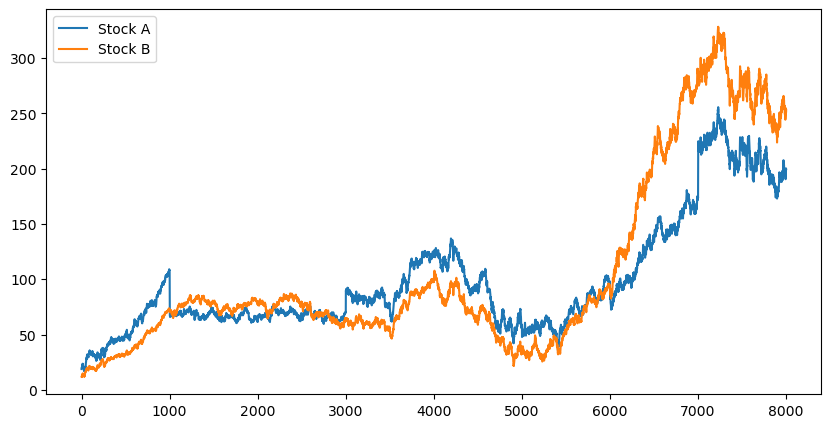

In [93]:
s1 = data_apple
s2 = data_microsoft

window_size = 400
points_per_window = 1000
s1_gen = [s1[0]]
s2_gen = [s2[0]]
et=s2[1]-s2[0]
epst=0
for i in range(len(s1)//window_size):
    params = estimate_all_params(s1[i*window_size:(i+1)*window_size], s2[i*window_size:(i+1)*window_size])
    for j in range(points_per_window):
        epst = params["c1"]+params["sigma1"]*np.random.normal()+params["phi1"]*epst
        et = params["c2"]+params["sigma2"]*np.random.normal()+params["phi2"]*et
        s2_gen.append(et+s2_gen[-1])
        s1_gen.append(epst-params["beta"]*s2_gen[-1]+params["intercept"])

for i in range(len(s1) // window_size):
    params = estimate_all_params(s1[i*window_size:(i+1)*window_size], s2[i*window_size:(i+1)*window_size])
    print(f"Window {i}: c1={params["c1"]} c2={params["c2"]} phi1={params['phi1']:.3f}, phi2={params['phi2']:.3f}, "
          f"sigma1={params['sigma1']:.4f}, sigma2={params['sigma2']:.4f}, "
          f"beta={params['beta']:.3f}")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(s1_gen, label = "Stock A")
ax.plot(s2_gen, label = "Stock B")
# ax.set_yscale('log')
ax.legend()
plt.show()

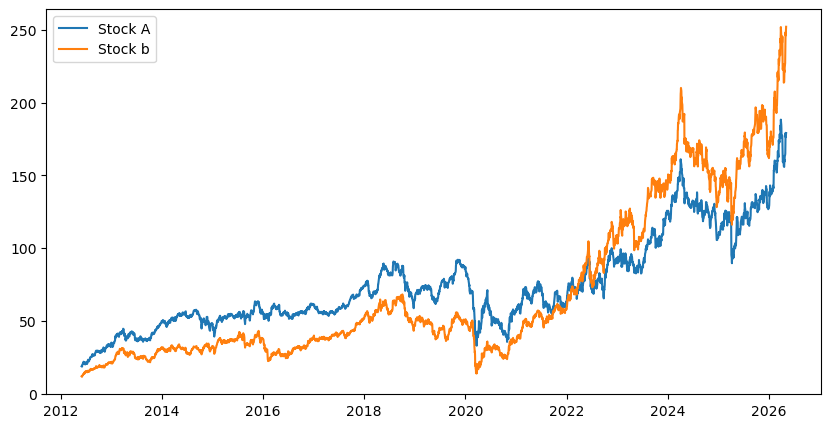

In [94]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(data_apple, label="Stock A")
ax.plot(data_microsoft, label="Stock b")
# ax.set_yscale('log')
ax.legend()

In [95]:
s1 = np.log(data_apple)
s2 = np.log(data_microsoft)

window_size = 300
points_per_window = 100
s1_gen = [s1[0]]
s2_gen = [s2[0]]
et=s2[1]-s2[0]
epst=0
betas = []
for i in range(len(s1)-window_size):
    params = estimate_all_params(s1[i:i+window_size], s2[i:i+window_size])
    betas.append(params["beta"])
    for j in range(points_per_window):
        epst = params["c1"]/points_per_window+params["sigma1"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window+params["phi1"]*epst
        et = params["c2"]/points_per_window+params["sigma2"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window+params["phi2"]*et
        s2_gen.append(et+s2_gen[-1])
        s1_gen.append(epst-params["beta"]*s2_gen[-1]+params["intercept"])

C:\Users\lpset\AppData\Local\Temp\ipykernel_3356\468606650.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s1_gen = [s1[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_3356\468606650.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s2_gen = [s2[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_3356\468606650.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  et=s2[1]-s2[0]


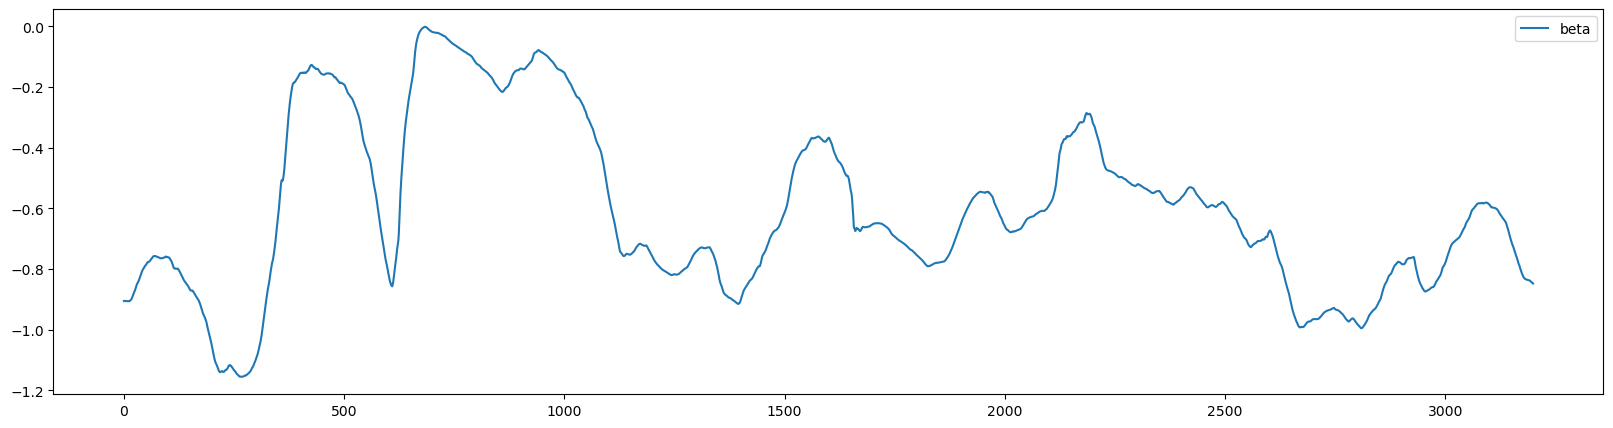

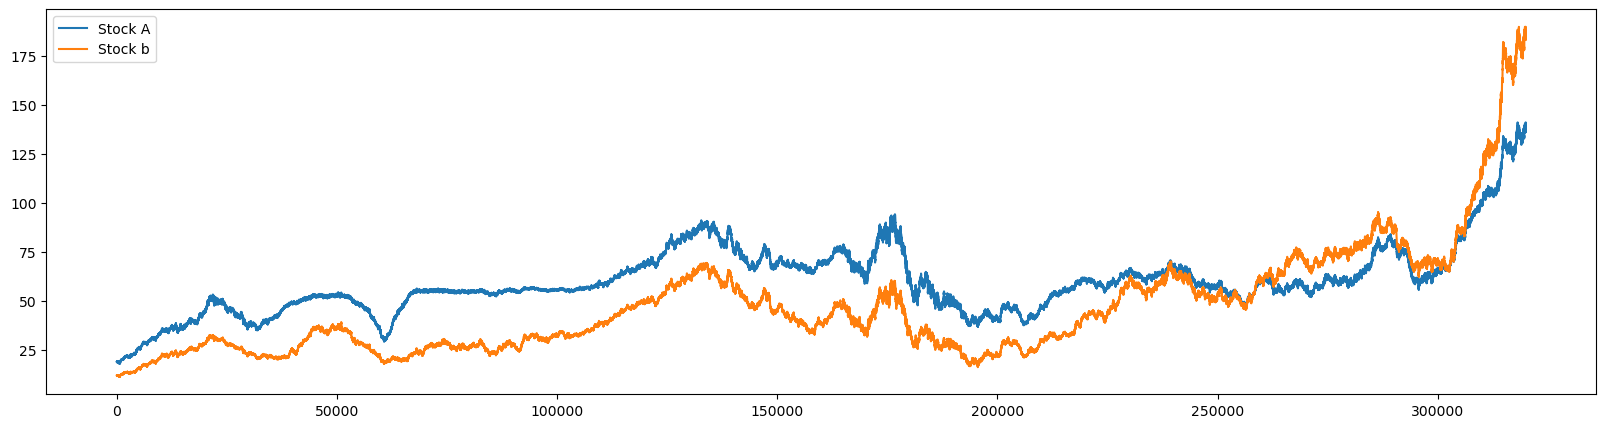

In [96]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(betas, label = "beta")
ax.legend()
plt.show()
s1_gen = np.array(s1_gen)
s2_gen = np.array(s2_gen)
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(np.exp(s1_gen[1:]), label="Stock A")
ax.plot(np.exp(s2_gen[1:]), label="Stock b")
# ax.set_yscale('log')
ax.legend()